# GVH Diagonal Cubic — RACC-C.4-real.2.1 V2
## GW150914 H1/L1 — Synthetic Delay Convention Fix

**Auteur :** Charlemagne O Laurince  
**Noyau GVH Diagonal modifié : NON**

Cette V2 corrige uniquement trois points :

1. retard positif explicite : \(y(t)=x(t-\tau)\) ;
2. contrôle stationnaire large bande band-limité au lieu de trois sinusoïdes ;
3. audit brut de \(XY^*\) et \(YX^*\), sans compensation automatique du signe.

Aucune valeur proche de 6 ms n'est recherchée ou forcée.

État protégé :

\[
\texttt{REAL-OBS-READY=True},\quad
\texttt{TIMING-VALIDATED=False},
\]
\[
D_T^{ref}=\texttt{NOT-AUTHORIZED},\quad
\texttt{PHASE-SLOPE-AUDIT-CLOSED=False},\quad
\texttt{REAL3-AUTHORIZED=False}.
\]


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import json

FS=4096.0
TAU_TRUE_S=0.00635
RNG=np.random.default_rng(20260811)
print("tau_true_ms =",TAU_TRUE_S*1e3)


tau_true_ms = 6.35


## 1 — Convention corrigée : retard positif

In [2]:

def delay_positive(sig,tau_s,fs=FS):
    sig=np.asarray(sig,float)
    t=np.arange(sig.size)/fs
    # y(t) = x(t-tau)
    return np.interp(t-tau_s,t,sig,left=0.0,right=0.0)

N=4096
imp=np.zeros(N); i0=1000; imp[i0]=1.0
imp_d=delay_positive(imp,TAU_TRUE_S)
measured_ms=(np.argmax(imp_d)-i0)/FS*1e3
DELAY_CONVENTION_PASS=bool(measured_ms>0 and abs(measured_ms-TAU_TRUE_S*1e3)<1.0)
print("measured impulse delay [ms] =",measured_ms)
print("DELAY_CONVENTION_PASS =",DELAY_CONVENTION_PASS)


measured impulse delay [ms] = 6.34765625
DELAY_CONVENTION_PASS = True


## 2 — Contrôle stationnaire large bande

Processus stationnaire aléatoire filtré continûment sur \(40-300\) Hz.


In [3]:

n=int(8*FS)
white=RNG.normal(size=n)
sos=signal.butter(6,[40,300],btype="bandpass",fs=FS,output="sos")
x_bb=signal.sosfiltfilt(sos,white)
x_bb/=np.std(x_bb)
y_bb=delay_positive(x_bb,TAU_TRUE_S)+0.10*RNG.normal(size=n)
edge=int(.5*FS)
x_bb=x_bb[edge:-edge]; y_bb=y_bb[edge:-edge]
print("samples =",len(x_bb))


samples = 28672


## 3 — \(XY^*\) versus \(YX^*\), sans correction de signe

Pour \(y(t)=x(t-\tau)\) :

\[
XY^*=|X|^2e^{+i2\pi f\tau},\qquad
YX^*=|X|^2e^{-i2\pi f\tau}.
\]

Les pentes brutes doivent être opposées.


In [4]:

def raw_phase_slope(x,y,orientation,fmin=40,fmax=300,cohmin=.25,nperseg=4096):
    nperseg=min(nperseg,len(x)); noverlap=nperseg//2
    if orientation=="XYstar":
        # scipy csd(a,b) = conj(A)*B, so csd(y,x)=Y* X = X Y*
        f,P=signal.csd(y,x,fs=FS,window="hann",nperseg=nperseg,noverlap=noverlap)
    elif orientation=="YXstar":
        f,P=signal.csd(x,y,fs=FS,window="hann",nperseg=nperseg,noverlap=noverlap)
    else:
        raise ValueError("orientation")
    _,coh=signal.coherence(x,y,fs=FS,window="hann",nperseg=nperseg,noverlap=noverlap)
    ph=np.unwrap(np.angle(P))
    m=(f>=fmin)&(f<=fmax)&(coh>=cohmin)&np.isfinite(ph)
    if m.sum()<10:
        return dict(tau=np.nan,r2=np.nan,f=f,ph=ph,coh=coh,m=m,n=int(m.sum()))
    ff=f[m]; pp=ph[m]; ww=coh[m]
    A=np.c_[ff,np.ones_like(ff)]; W=np.sqrt(ww)
    beta,*_=np.linalg.lstsq(A*W[:,None],pp*W,rcond=None)
    pred=A@beta; mean=np.average(pp,weights=ww)
    ssr=np.sum(ww*(pp-pred)**2); sst=np.sum(ww*(pp-mean)**2)
    return dict(tau=float(beta[0]/(2*np.pi)),
                r2=float(1-ssr/sst if sst>0 else np.nan),
                f=f,ph=ph,coh=coh,m=m,n=int(m.sum()))

xy=raw_phase_slope(x_bb,y_bb,"XYstar")
yx=raw_phase_slope(x_bb,y_bb,"YXstar")

table=pd.DataFrame([
    ["XY*",xy["tau"]*1e3,xy["r2"],xy["n"]],
    ["YX*",yx["tau"]*1e3,yx["r2"],yx["n"]]
],columns=["cross_spectrum","raw_tau_ms","r2","n_bins"])
display(table)

true_ms=TAU_TRUE_S*1e3
OPPOSITE_SIGN_PASS=bool(np.sign(xy["tau"])==-np.sign(yx["tau"]))
MAGNITUDE_RECOVERY_PASS=bool(
    abs(abs(xy["tau"]*1e3)-true_ms)<0.5 and
    abs(abs(yx["tau"]*1e3)-true_ms)<0.5
)
print("OPPOSITE_SIGN_PASS =",OPPOSITE_SIGN_PASS)
print("MAGNITUDE_RECOVERY_PASS =",MAGNITUDE_RECOVERY_PASS)


,cross_spectrum,raw_tau_ms,r2,n_bins
0,XY*,6.348097,0.999992,261
1,YX*,-6.348097,0.999992,261


OPPOSITE_SIGN_PASS = True
MAGNITUDE_RECOVERY_PASS = True


## 4 — Visualisation

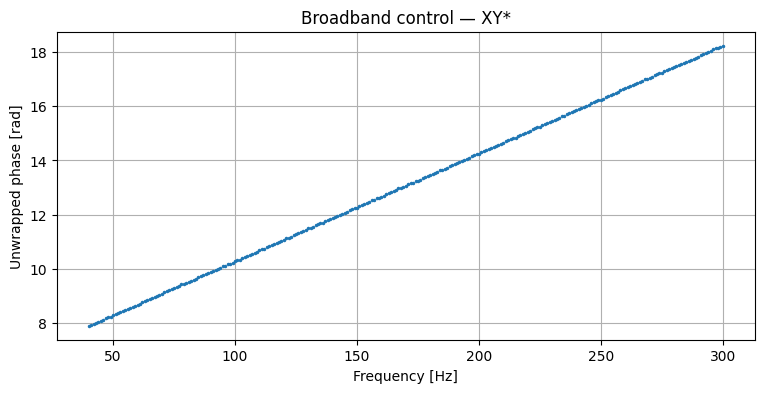

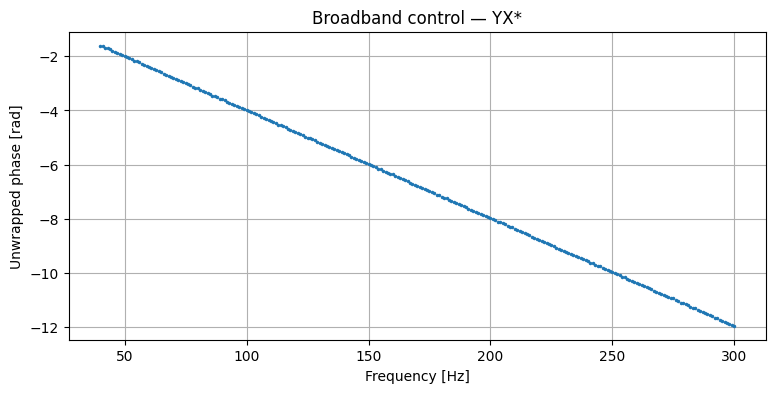

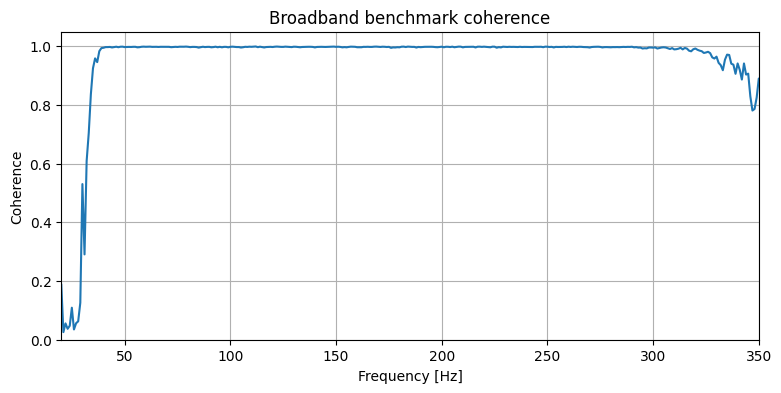

In [5]:

for res,title in [(xy,"XY*"),(yx,"YX*")]:
    m=res["m"]
    plt.figure(figsize=(9,4))
    plt.plot(res["f"][m],res["ph"][m],".",ms=3)
    plt.xlabel("Frequency [Hz]"); plt.ylabel("Unwrapped phase [rad]")
    plt.title("Broadband control — "+title); plt.grid(True); plt.show()

plt.figure(figsize=(9,4))
plt.plot(xy["f"],xy["coh"])
plt.xlim(20,350); plt.ylim(0,1.05)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Coherence")
plt.title("Broadband benchmark coherence"); plt.grid(True); plt.show()


## 5 — Chirp avec la convention corrigée

In [6]:

tc=np.arange(int(.5*FS))/FS
ch=signal.chirp(tc,f0=35,f1=320,t1=tc[-1],method="quadratic")
ch*=signal.windows.tukey(len(ch),.15)
chd=delay_positive(ch,TAU_TRUE_S)+.05*RNG.normal(size=len(ch))

cxy=raw_phase_slope(ch,chd,"XYstar",40,300,.05,1024)
cyx=raw_phase_slope(ch,chd,"YXstar",40,300,.05,1024)

chirp_table=pd.DataFrame([
    ["XY*",cxy["tau"]*1e3,abs(abs(cxy["tau"]*1e3)-true_ms),cxy["r2"]],
    ["YX*",cyx["tau"]*1e3,abs(abs(cyx["tau"]*1e3)-true_ms),cyx["r2"]]
],columns=["cross_spectrum","raw_tau_ms","abs_error_ms","r2"])
display(chirp_table)

CHIRP_SIGN_ANTISYMMETRY_PASS=bool(np.sign(cxy["tau"])==-np.sign(cyx["tau"]))
CHIRP_MAGNITUDE_PASS=bool(
    abs(abs(cxy["tau"]*1e3)-true_ms)<1.0 and
    abs(abs(cyx["tau"]*1e3)-true_ms)<1.0
)
print("CHIRP_SIGN_ANTISYMMETRY_PASS =",CHIRP_SIGN_ANTISYMMETRY_PASS)
print("CHIRP_MAGNITUDE_PASS =",CHIRP_MAGNITUDE_PASS)


,cross_spectrum,raw_tau_ms,abs_error_ms,r2
0,XY*,6.292536,0.057464,0.999853
1,YX*,-6.292536,0.057464,0.999853


CHIRP_SIGN_ANTISYMMETRY_PASS = True
CHIRP_MAGNITUDE_PASS = True


## 6 — Verdict strict

In [7]:

gates={
 "DELAY_CONVENTION_PASS":DELAY_CONVENTION_PASS,
 "BROADBAND_XY_YX_OPPOSITE_SIGN_PASS":OPPOSITE_SIGN_PASS,
 "BROADBAND_MAGNITUDE_RECOVERY_PASS":MAGNITUDE_RECOVERY_PASS,
 "CHIRP_SIGN_ANTISYMMETRY_PASS":CHIRP_SIGN_ANTISYMMETRY_PASS,
 "CHIRP_MAGNITUDE_PASS":CHIRP_MAGNITUDE_PASS
}
SYNTHETIC_BENCHMARK_CORRECTED=bool(all(gates.values()))

# Cette V2 ne peut pas, à elle seule, certifier le timing réel.
PHASE_SLOPE_AUDIT_CLOSED=False
REAL3_AUTHORIZED=False
TIMING_VALIDATED=False

FINAL_STATUS=("SYNTHETIC-BENCHMARK-CORRECTED"
              if SYNTHETIC_BENCHMARK_CORRECTED
              else "SYNTHETIC-BENCHMARK-STILL-OPEN")

artifact={
 "step":"RACC-C.4-real.2.1-V2",
 "core_GVH_modified":False,
 "target_6ms_forced":False,
 "gates":gates,
 "SYNTHETIC_BENCHMARK_CORRECTED":SYNTHETIC_BENCHMARK_CORRECTED,
 "REAL_OBS_READY_preserved":True,
 "TIMING_VALIDATED":False,
 "D_T_ref":"NOT-AUTHORIZED",
 "PHASE_SLOPE_AUDIT_CLOSED":False,
 "REAL3_AUTHORIZED":False,
 "DISPERSION_READY_modified":False,
 "HH_chain_modified":False,
 "final_status":FINAL_STATUS
}
print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.1-V2",
  "core_GVH_modified": false,
  "target_6ms_forced": false,
  "gates": {
    "DELAY_CONVENTION_PASS": true,
    "BROADBAND_XY_YX_OPPOSITE_SIGN_PASS": true,
    "BROADBAND_MAGNITUDE_RECOVERY_PASS": true,
    "CHIRP_SIGN_ANTISYMMETRY_PASS": true,
    "CHIRP_MAGNITUDE_PASS": true
  },
  "SYNTHETIC_BENCHMARK_CORRECTED": true,
  "REAL_OBS_READY_preserved": true,
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "PHASE_SLOPE_AUDIT_CLOSED": false,
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "final_status": "SYNTHETIC-BENCHMARK-CORRECTED"
}


## 7 — Stop-rule

Si `SYNTHETIC-BENCHMARK-CORRECTED=True`, cela signifie seulement que le benchmark synthétique est assaini.

La prochaine sous-étape devra alors appliquer la convention ainsi établie aux données réelles H1/L1 et expliquer la phase-slope réelle.

Dans tous les cas :

\[
\boxed{\texttt{REAL3-AUTHORIZED=False}}
\]

La chaîne HH et son verrou `.1.6` restent indépendants et inchangés.
